# Function Transformation

uses for convert non normal Distribution data to normal Distribtion data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
dataset = pd.read_csv("loan.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,NaN,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,NaN,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     16
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

/tmp/ipykernel_31565/1899262194.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])


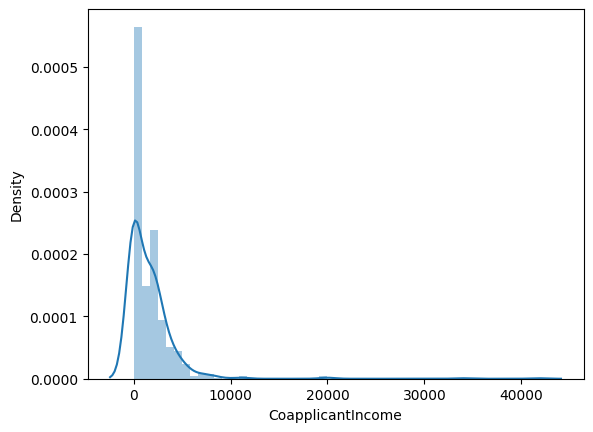

In [4]:
sns.distplot(dataset["CoapplicantIncome"])
plt.show()

In [ ]:
# First remove Outliers : By IQR method

q1 = dataset["CoapplicantIncome"].quantile(0.25)
q3 = dataset["CoapplicantIncome"].quantile(0.75)

iqr = q3 - q1

In [6]:
min_r  = q1 - (1.5*iqr)
max_r = q3 + (1.5*iqr)
min_r , max_r

(np.float64(-3445.875), np.float64(5743.125))

In [7]:
dataset = dataset[dataset["CoapplicantIncome"]<= max_r]

/tmp/ipykernel_31565/1899262194.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])


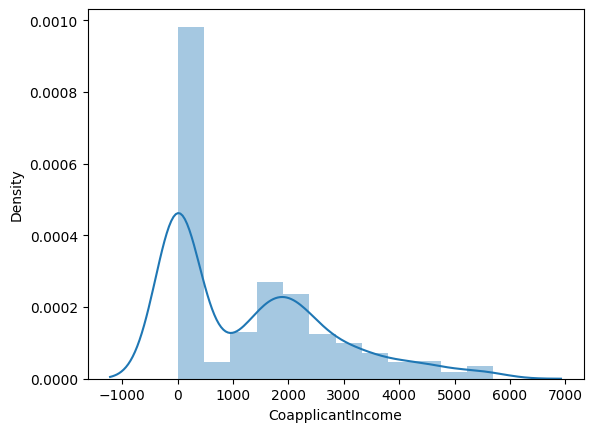

In [8]:
sns.distplot(dataset["CoapplicantIncome"])
plt.show()

In [9]:
#  Function transfrom : 

from sklearn.preprocessing import FunctionTransformer

ft = FunctionTransformer(func=np.log1p)
ft.fit(dataset[["CoapplicantIncome"]])

dataset["CoapplicanIncome_ft"] = ft.transform(dataset[["CoapplicantIncome"]])
dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,CoapplicanIncome_ft
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,NaN,1.0,Urban,Y,0.000000
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,NaN,1.0,Rural,N,7.319202
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,0.000000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.765993
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,0.000000
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,0.000000
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,5.484797
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,0.000000


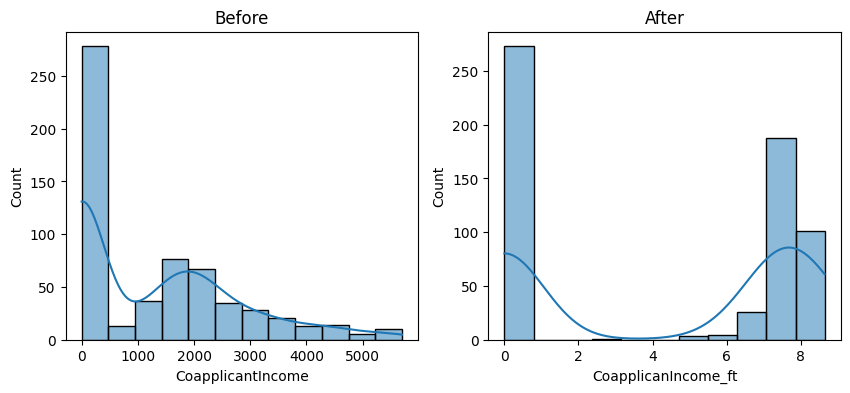

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Before")
sns.histplot(dataset["CoapplicantIncome"],kde = True)

plt.subplot(1,2,2)
plt.title("After")
sns.histplot(dataset["CoapplicanIncome_ft"] , kde = True)
plt.show()


In [ ]:

ft1 = FunctionTransformer(func= lambda x : x**2)
ft1.fit(dataset[["CoapplicantIncome"]])

dataset["CoapplicanIncome_ft1"] = ft1.transform(dataset[["CoapplicantIncome"]])

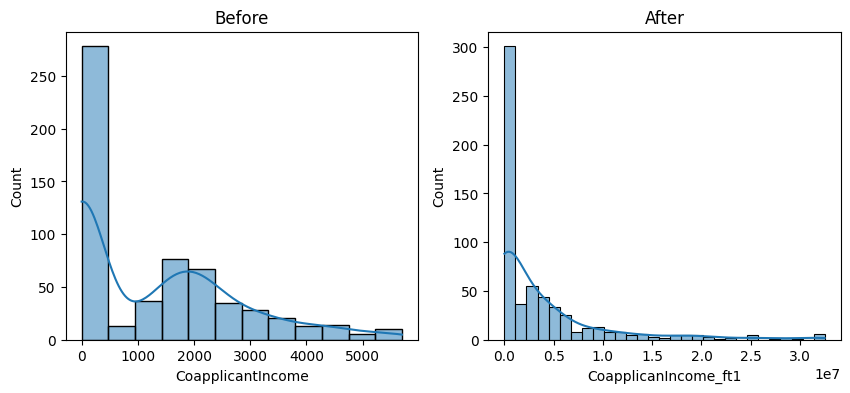

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Before")
sns.histplot(dataset["CoapplicantIncome"],kde = True)

plt.subplot(1,2,2)
plt.title("After")
sns.histplot(dataset["CoapplicanIncome_ft1"] , kde = True)
plt.show()